In [1]:
import matplotlib.pyplot as plt
import mlflow
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from sklearn.compose import ColumnTransformer
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, roc_auc_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from torch.utils.data import DataLoader, Dataset

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device('mps' if torch.backends.mps.is_available() else 'cpu')
print(f"Usando dispositivo: {device}")
print(f"PyTorch versão: {torch.__version__}")

/Users/rafaelnedermaiorino/projetos/tech-challenge-fase1/venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


Usando dispositivo: mps
PyTorch versão: 2.8.0


In [2]:
# Carregar e preparar dados
df = pd.read_csv('../data/telco_churn.csv')
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df['TotalCharges'] = df['TotalCharges'].fillna(df['TotalCharges'].median())
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})
df = df.drop('customerID', axis=1)

X = df.drop('Churn', axis=1)
y = df['Churn']

num_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
cat_cols = X.select_dtypes(include=['object']).columns.tolist()

# Pré-processamento
preprocessor = ColumnTransformer([
    ('num', StandardScaler(), num_cols),
    ('cat', OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore'), cat_cols)
])

# Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=SEED, stratify=y)

# Transformar
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

n_features = X_train_processed.shape[1]
print(f"Features após pré-processamento: {n_features}")
print(f"Treino: {X_train_processed.shape[0]} | Teste: {X_test_processed.shape[0]}")

Features após pré-processamento: 30
Treino: 5634 | Teste: 1409


In [3]:
# Custom Dataset
class ChurnDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.FloatTensor(X)
        self.y = torch.FloatTensor(y.values)

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

# Criar DataLoaders
train_dataset = ChurnDataset(X_train_processed, y_train)
test_dataset = ChurnDataset(X_test_processed, y_test)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

# Definir a MLP
class ChurnMLP(nn.Module):
    def __init__(self, input_size):
        super(ChurnMLP, self).__init__()
        self.network = nn.Sequential(
            nn.Linear(input_size, 64),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(32, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.network(x).squeeze()

model = ChurnMLP(n_features).to(device)
print(model)
print(f"\nTotal de parâmetros: {sum(p.numel() for p in model.parameters()):,}")

ChurnMLP(
  (network): Sequential(
    (0): Linear(in_features=30, out_features=64, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=64, out_features=32, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.3, inplace=False)
    (6): Linear(in_features=32, out_features=1, bias=True)
    (7): Sigmoid()
  )
)

Total de parâmetros: 4,097


In [4]:
# Configurar treinamento
criterion = nn.BCELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

# Early stopping
best_val_loss = float('inf')
patience = 10
patience_counter = 0
best_model_state = None

train_losses = []
val_losses = []
n_epochs = 100

# Split treino em treino/validação para early stopping
X_tr, X_val, y_tr, y_val = train_test_split(
    X_train_processed, y_train, test_size=0.2, random_state=SEED, stratify=y_train
)

tr_dataset = ChurnDataset(X_tr, y_tr)
val_dataset = ChurnDataset(X_val, y_val)
tr_loader = DataLoader(tr_dataset, batch_size=64, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False)

# Loop de treinamento
for epoch in range(n_epochs):
    # Treino
    model.train()
    epoch_train_loss = 0
    for X_batch, y_batch in tr_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        optimizer.zero_grad()
        y_pred = model(X_batch)
        loss = criterion(y_pred, y_batch)
        loss.backward()
        optimizer.step()
        epoch_train_loss += loss.item()

    # Validação
    model.eval()
    epoch_val_loss = 0
    with torch.no_grad():
        for X_batch, y_batch in val_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            y_pred = model(X_batch)
            loss = criterion(y_pred, y_batch)
            epoch_val_loss += loss.item()

    avg_train_loss = epoch_train_loss / len(tr_loader)
    avg_val_loss = epoch_val_loss / len(val_loader)
    train_losses.append(avg_train_loss)
    val_losses.append(avg_val_loss)

    # Early stopping
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        patience_counter = 0
        best_model_state = model.state_dict().copy()
    else:
        patience_counter += 1

    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch+1:3d} | Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f} | Patience: {patience_counter}/{patience}")

    if patience_counter >= patience:
        print(f"\n⛔ Early stopping na epoch {epoch+1}")
        break

# Restaurar melhor modelo
model.load_state_dict(best_model_state)
print(f"\n✅ Treinamento concluído! Melhor val_loss: {best_val_loss:.4f}")

Epoch  10 | Train Loss: 0.4194 | Val Loss: 0.4192 | Patience: 5/10

⛔ Early stopping na epoch 15

✅ Treinamento concluído! Melhor val_loss: 0.4158


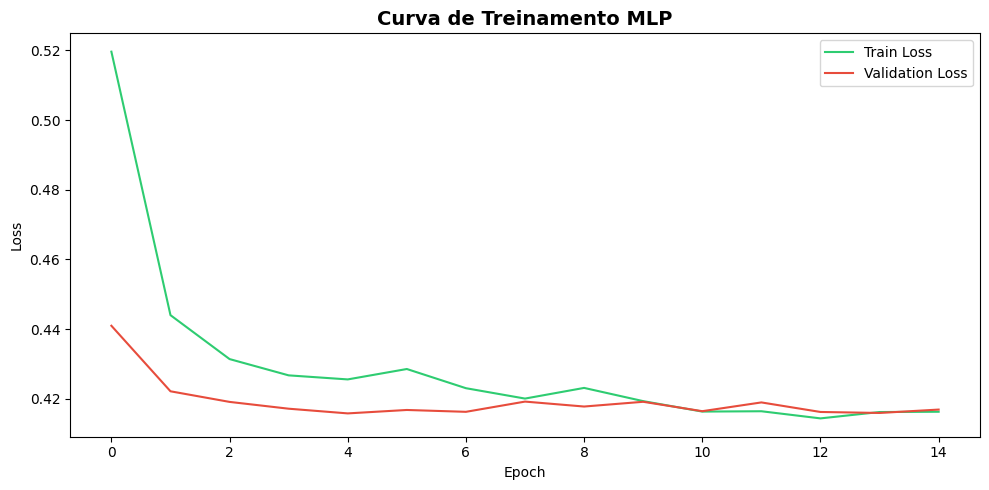

MÉTRICAS MLP NO TESTE:
  Accuracy: 0.8034
  F1-Score: 0.5758
  AUC-ROC: 0.8438
  Precision: 0.6738
  Recall: 0.5027

TABELA COMPARATIVA — TODOS OS MODELOS


,Modelo,Accuracy,F1-Score,AUC-ROC,Precision,Recall
0,DummyClassifier,0.734600,0.000000,0.500000,0.000000,0.000000
1,Logistic Regression,0.808400,0.603400,0.843300,0.655700,0.558800
2,Random Forest,0.784900,0.547900,0.832300,0.623000,0.489300
3,MLP (PyTorch),0.803407,0.575804,0.843778,0.673835,0.502674


In [5]:
# Gráfico de loss
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(train_losses, label='Train Loss', color='#2ecc71')
ax.plot(val_losses, label='Validation Loss', color='#e74c3c')
ax.set_xlabel('Epoch')
ax.set_ylabel('Loss')
ax.set_title('Curva de Treinamento MLP', fontsize=14, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig('../docs/mlp_training_curve.png', dpi=150, bbox_inches='tight')
plt.show()

# Avaliar no conjunto de teste
model.eval()
X_test_tensor = torch.FloatTensor(X_test_processed).to(device)
with torch.no_grad():
    y_proba_mlp = model(X_test_tensor).cpu().numpy()
    y_pred_mlp = (y_proba_mlp >= 0.5).astype(int)

# Métricas MLP
mlp_metrics = {
    'Accuracy': accuracy_score(y_test, y_pred_mlp),
    'F1-Score': f1_score(y_test, y_pred_mlp),
    'AUC-ROC': roc_auc_score(y_test, y_proba_mlp),
    'Precision': precision_score(y_test, y_pred_mlp),
    'Recall': recall_score(y_test, y_pred_mlp)
}

print("MÉTRICAS MLP NO TESTE:")
for metric, value in mlp_metrics.items():
    print(f"  {metric}: {value:.4f}")

# Tabela comparativa completa
print("\n" + "="*70)
print("TABELA COMPARATIVA — TODOS OS MODELOS")
print("="*70)

comparison = pd.DataFrame([
    {'Modelo': 'DummyClassifier', 'Accuracy': 0.7346, 'F1-Score': 0.0000, 'AUC-ROC': 0.5000, 'Precision': 0.0000, 'Recall': 0.0000},
    {'Modelo': 'Logistic Regression', 'Accuracy': 0.8084, 'F1-Score': 0.6034, 'AUC-ROC': 0.8433, 'Precision': 0.6557, 'Recall': 0.5588},
    {'Modelo': 'Random Forest', 'Accuracy': 0.7849, 'F1-Score': 0.5479, 'AUC-ROC': 0.8323, 'Precision': 0.6230, 'Recall': 0.4893},
    {'Modelo': 'MLP (PyTorch)', **mlp_metrics}
])
comparison

In [6]:
# Registrar MLP no MLflow
mlflow.set_experiment("churn-mlp")

with mlflow.start_run(run_name="MLP-PyTorch"):
    mlflow.log_param("model_name", "MLP-PyTorch")
    mlflow.log_param("architecture", "30-64-32-1")
    mlflow.log_param("activation", "ReLU")
    mlflow.log_param("dropout", 0.3)
    mlflow.log_param("optimizer", "Adam")
    mlflow.log_param("learning_rate", 0.001)
    mlflow.log_param("batch_size", 64)
    mlflow.log_param("epochs_trained", len(train_losses))
    mlflow.log_param("early_stopping_patience", patience)
    mlflow.log_param("seed", SEED)

    for metric, value in mlp_metrics.items():
        mlflow.log_metric(metric.lower().replace('-', '_'), value)

    # Salvar modelo
    torch.save(model.state_dict(), '../models/mlp_churn.pt')
    mlflow.log_artifact('../models/mlp_churn.pt')

    print("✅ MLP registrada no MLflow")

# Análise de trade-off de custo
print("\n" + "="*60)
print("ANÁLISE DE TRADE-OFF DE CUSTO")
print("="*60)

custo_fn = 200   # Custo de perder um cliente (falso negativo)
custo_fp = 30    # Custo de oferecer desconto desnecessário (falso positivo)

print("\nPremissas:")
print(f"  Custo Falso Negativo (perder cliente): R${custo_fn}")
print(f"  Custo Falso Positivo (desconto inútil): R${custo_fp}")

# Testar diferentes thresholds
print(f"\n{'Threshold':>10} | {'Recall':>8} | {'Precision':>10} | {'F1':>8} | {'Custo Total':>12}")
print("-" * 60)

best_cost = float('inf')
best_threshold = 0.5

for threshold in [0.3, 0.35, 0.4, 0.45, 0.5, 0.55, 0.6]:
    y_pred_t = (y_proba_mlp >= threshold).astype(int)

    fn = ((y_test == 1) & (y_pred_t == 0)).sum()
    fp = ((y_test == 0) & (y_pred_t == 1)).sum()

    custo_total = fn * custo_fn + fp * custo_fp
    rec = recall_score(y_test, y_pred_t)
    prec = precision_score(y_test, y_pred_t, zero_division=0)
    f1 = f1_score(y_test, y_pred_t)

    if custo_total < best_cost:
        best_cost = custo_total
        best_threshold = threshold

    print(f"{threshold:>10.2f} | {rec:>8.4f} | {prec:>10.4f} | {f1:>8.4f} | R${custo_total:>10,}")

print(f"\n🎯 Melhor threshold por custo: {best_threshold} (custo total: R${best_cost:,})")

2026/04/19 12:32:41 INFO mlflow.tracking.fluent: Experiment with name 'churn-mlp' does not exist. Creating a new experiment.


✅ MLP registrada no MLflow

ANÁLISE DE TRADE-OFF DE CUSTO

Premissas:
  Custo Falso Negativo (perder cliente): R$200
  Custo Falso Positivo (desconto inútil): R$30

 Threshold |   Recall |  Precision |       F1 |  Custo Total
------------------------------------------------------------
      0.30 |   0.7433 |     0.5285 |   0.6178 | R$    26,640
      0.35 |   0.6952 |     0.5603 |   0.6205 | R$    28,920
      0.40 |   0.6417 |     0.5882 |   0.6138 | R$    31,840
      0.45 |   0.5722 |     0.6276 |   0.5986 | R$    35,810
      0.50 |   0.5027 |     0.6738 |   0.5758 | R$    39,930
      0.55 |   0.4278 |     0.6957 |   0.5298 | R$    44,900
      0.60 |   0.3449 |     0.7247 |   0.4674 | R$    50,470

🎯 Melhor threshold por custo: 0.3 (custo total: R$26,640)
